# 데이터 분석가 채용공고 분석
분석흐름
1. 데이터 로드 및 기본설정
2. 채용시장 현황 분석
3. 요구 스킬 분석
4. 산업군별 스킬 비교
5. 산업군별 직무 역량
6. 텍스트 분석
7. 결론 및 한계점 정리

## 1. 데이터 로드 및 기본설정

In [124]:
import re
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')
from collections import Counter

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
df = pd.read_csv('../data/active_jobs_06.11.csv', encoding='utf-8-sig')

# 결측치 처리
df = df.fillna('')

print('총 공고 수:', len(df))
display(df.head())
print(df.info())

총 공고 수: 430


,source,company,title,industry,location,experience,employment_type,salary,skills,deadline,url,description,crawled_at
0,원티드,나이스지니데이타,신용평가/리스크 모델 개발,금융·보험,서울 영등포구,3.0,계약직,미공개,"SQL, 통계",2026-07-31,https://www.wanted.co.kr/wd/367167,ㆍ신용평가/리스크 모델 개발 및 데이터 컨설팅 프로젝트 수행 (상주 및 비상주) ㆍ...,2026-06-11 09:30
1,원티드,티오더,Data Analyst,미디어·콘텐츠,서울 영등포구,3.0,정규직,미공개,", , , , , ,",상시채용,https://www.wanted.co.kr/wd/366901,• AI 서비스 도입 전후 매장 매출 변화를 측정하고 성과 분석을 통해 비즈니스 가...,2026-06-11 09:30
2,원티드,쿠팡,Staff Data Analyst (Coupang Logistics Service),이커머스·유통,서울 광진구,5.0,정규직,미공개,"SQL, ETL, Tableau, Power BI, A/B, 통계, Python",상시채용,https://www.wanted.co.kr/wd/366729,"End-to-End 데이터 분석\n• 비즈니스 문제를 데이터 기반으로 정의하고, 가...",2026-06-11 09:30
3,원티드,프라이데이즈랩(Retentics),[리텐틱스] 데이터 사이언티스트 (Data Scientist) 5년 이상,이커머스·유통,서울 강남구,5.0,정규직,미공개,"SQL, Python",2026-06-30,https://www.wanted.co.kr/wd/365648,리텐틱스의 데이터 사이언티스트는 AI 기반 이메일 마케팅 SaaS 프로덕트의 핵심을...,2026-06-11 09:30
4,원티드,레트리카(Retrica),그로스 매니저 (Growth Manager),미디어·콘텐츠,서울 강남구,0.0,정규직,미공개,", , , ,",2026-06-30,https://www.wanted.co.kr/wd/365646,• 퍼널·코호트·리텐션 데이터 분석을 통한 성장 기회 발굴 및 핵심 지표 정의\n•...,2026-06-11 09:30


<class 'pandas.DataFrame'>
RangeIndex: 430 entries, 0 to 429
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   source           430 non-null    str   
 1   company          430 non-null    str   
 2   title            430 non-null    str   
 3   industry         430 non-null    str   
 4   location         430 non-null    str   
 5   experience       430 non-null    object
 6   employment_type  430 non-null    str   
 7   salary           430 non-null    str   
 8   skills           430 non-null    str   
 9   deadline         430 non-null    str   
 10  url              430 non-null    str   
 11  description      430 non-null    str   
 12  crawled_at       430 non-null    str   
dtypes: object(1), str(12)
memory usage: 43.8+ KB
None


## 2. 채용시장 현황 분석

플랫폼별, 산업군별, 지역별, 경력별로 채용공고 분포 확인

source
사람인     135
잡코리아    104
원티드      98
리멤버      93
Name: count, dtype: int64

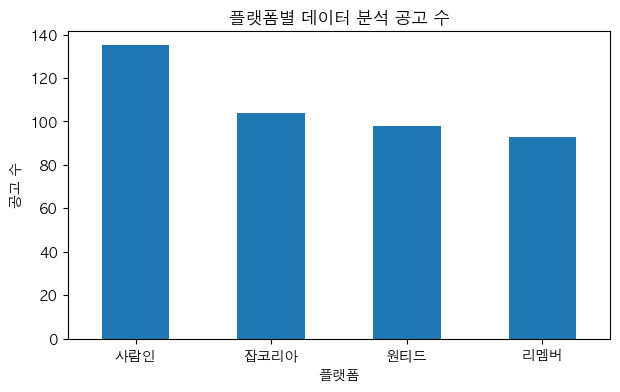

In [105]:
# 플랫폼별 공고 수
source_counts = df['source'].value_counts()

display(source_counts)

plt.figure(figsize=(7, 4))
source_counts.plot(kind='bar')
plt.title('플랫폼별 데이터 분석 공고 수')
plt.xlabel('플랫폼')
plt.ylabel('공고 수')
plt.xticks(rotation=0)
plt.show()

industry
이커머스·유통        102
IT·플랫폼·SaaS     67
금융·보험           48
미디어·콘텐츠         48
기타              46
헤드헌팅            39
헬스케어·바이오        31
교육              28
제조·모빌리티         19
공공기관             2
Name: count, dtype: int64

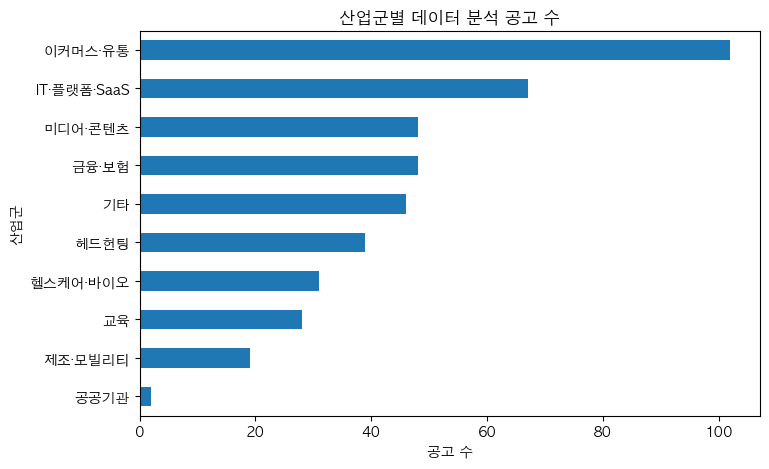

In [ ]:
# 산업군별 공고 수
industry_counts = df['industry'].value_counts()

display(industry_counts)

plt.figure(figsize=(8, 5))
industry_counts.sort_values().plot(kind='barh')
plt.title('산업군별 데이터 분석 공고 수')
plt.xlabel('공고 수')
plt.ylabel('산업군')
plt.show()

location
서울 강남구        128
서울특별시 강남구      35
서울 송파구         26
서울 서초구         25
경기 성남시 분당구     21
서울 영등포구        18
서울 구로구         15
서울특별시 송파구      14
서울 중구          12
서울특별시 전체       11
서울 종로구         10
서울 마포구         10
서울 성동구          9
서울 금천구          6
서울 강서구          5
Name: count, dtype: int64

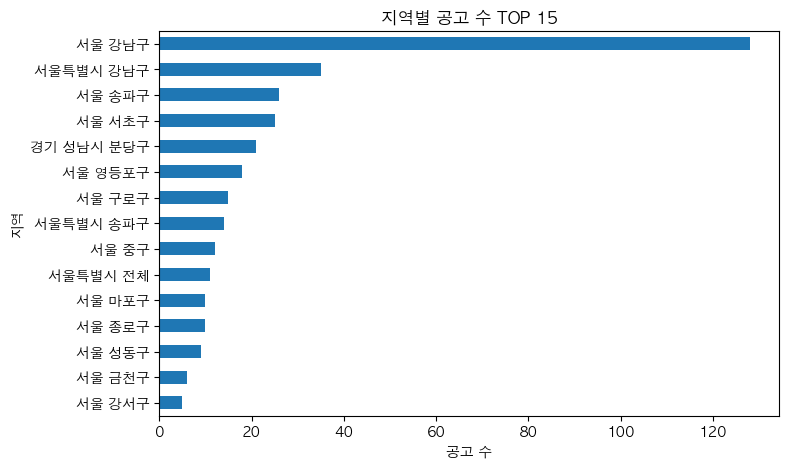

In [ ]:
# 지역별 공고 수 TOP 15
location_counts = df["location"].value_counts().head(15)

display(location_counts)

plt.figure(figsize=(8, 5))
location_counts.sort_values().plot(kind="barh")
plt.title("지역별 공고 수 TOP 15")
plt.xlabel("공고 수")
plt.ylabel("지역")
plt.show()


count    402.000000
mean       3.315920
std        2.798681
min        0.000000
25%        1.000000
50%        3.000000
75%        5.000000
max       15.000000
Name: experience_num, dtype: float64

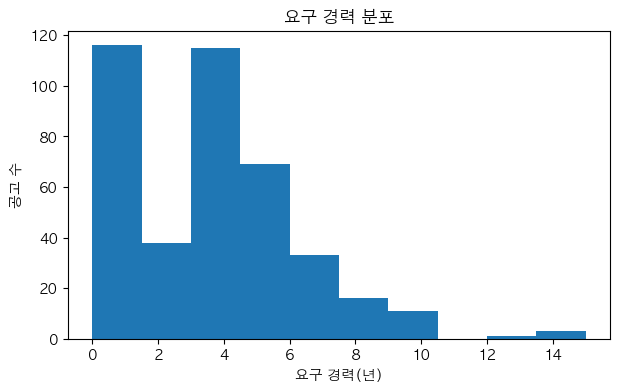

In [107]:
# 경력 분석
df['experience_num'] = pd.to_numeric(df['experience'], errors='coerce')

display(df['experience_num'].describe())

plt.figure(figsize=(7, 4))
df['experience_num'].dropna().plot(kind='hist', bins=10)
plt.title('요구 경력 분포')
plt.xlabel('요구 경력(년)')
plt.ylabel('공고 수')
plt.show()

## 현황 분석
- 전체 공고는 430건 기준으로 분석함.
- 플랫폼별로는 사람인, 잡코리아, 원티드, 리멤버 순으로 공고가 많음. 플랫폼 특성이 반영되어서 똑같은 수만큼 모집공고가 수집되지 않았음.
- 산업군은 이커머스·유통, IT·플랫폼·SaaS, 금융·보험 순으로 높은 비중을 보였음.
- 지역은 서울, 특히 강남권 중심으로 공고가 집중되었음.
- 요구 경력은 평균 약 3년으로 주니어~ 미들급 경력 수요가 중심.

## 3. 요구스킬 분석
skills 컬럼은 크롤링 및 정제 과정에서 추출한 키워드
공고별로 쉼표로 분리되어있으므로, 이를 하나씩 분리한 뒤 빈도 수 계산

In [109]:
# 스킬 키워드 TOP 10
skills = []

for skill_text in df["skills"].fillna(""):
    for skill in str(skill_text).split(","):
        skill = skill.strip()
        if skill and skill != "미확인":
            skills.append(skill)

skill_counts = pd.DataFrame(
    Counter(skills).items(),
    columns=["skill", "count"]
).sort_values("count", ascending=False)

skill_counts["ratio"] = (skill_counts["count"] / len(df) * 100).round(1)

display(skill_counts.head(10))


,skill,count,ratio
0,SQL,218,50.7
6,Python,160,37.2
1,통계,83,19.3
3,Tableau,65,15.1
5,A/B,63,14.7
15,KPI,62,14.4
4,Power BI,30,7.0
2,ETL,27,6.3
22,퍼널,25,5.8
30,전처리,22,5.1


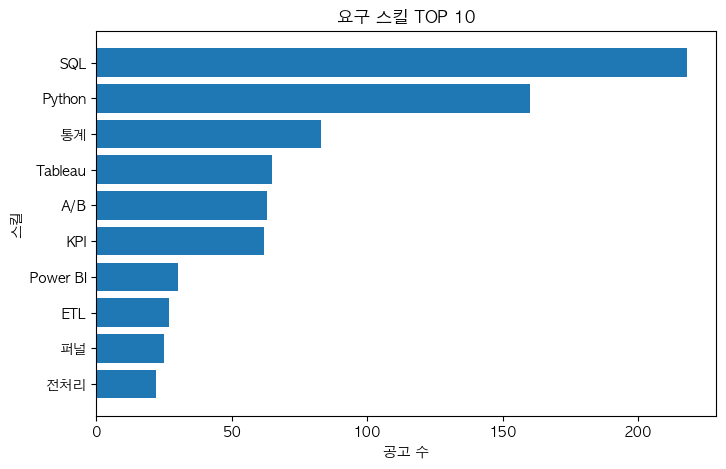

In [111]:
# 스킬 TOP 10 시각화
top10_skills = skill_counts.head(10).sort_values("count")

plt.figure(figsize=(8, 5))
plt.barh(top10_skills["skill"], top10_skills["count"])
plt.title("요구 스킬 TOP 10")
plt.xlabel("공고 수")
plt.ylabel("스킬")
plt.show()

### 스킬 분석
- SQL은 전체 공고의 약 절반 이상이 등장해 가장 보편적인 핵심 역량으로 확인됨.
- Python은 SQL 다음으로 많이 등장 Tableau 및 Power BI 등 시각화 툴도 상위권에 있어
분석 결과를 대시보드로 전달하는 역량이 중요함읋 확인하였음.

## 4. 산업군별 주요 스킬 비교

In [112]:
def get_top_skills_by_industry(data, industry_name, top_n=5):
    temp = data[data["industry"] == industry_name]
    skill_list = []

    for skill_text in temp["skills"].fillna(""):
        for skill in str(skill_text).split(","):
            skill = skill.strip()
            if skill and skill != "미확인":
                skill_list.append(skill)

    result = pd.DataFrame(
        Counter(skill_list).most_common(top_n),
        columns=["skill", "count"]
    )

    result["industry"] = industry_name
    return result


industry_skill_list = []

for industry in df["industry"].value_counts().index:
    industry_skill_list.append(
        get_top_skills_by_industry(df, industry, top_n=5)
    )

industry_skill_df = pd.concat(industry_skill_list, ignore_index=True)

display(industry_skill_df)


,skill,count,industry
0,SQL,79,이커머스·유통
1,Python,49,이커머스·유통
2,Tableau,32,이커머스·유통
3,통계,31,이커머스·유통
4,A/B,26,이커머스·유통
5,SQL,30,IT·플랫폼·SaaS
6,Python,23,IT·플랫폼·SaaS
7,Tableau,9,IT·플랫폼·SaaS
8,통계,8,IT·플랫폼·SaaS
9,A/B,7,IT·플랫폼·SaaS


In [163]:
# 주요 산업군 간 스킬 비율 비교
target_industries = ["금융·보험", "이커머스·유통", "IT·플랫폼·SaaS", "미디어·콘텐츠"]

compare_rows = []

for industry in target_industries:
    temp = df[df["industry"] == industry]
    for skill in ["SQL", "Python", "통계", "Tableau", "A/B", "KPI", "Power BI", "ETL", "퍼널", "GA4"]:
        count = temp["skills"].fillna("").str.contains(skill, case=False, regex=False).sum()
        ratio = count / len(temp) * 100 if len(temp) > 0 else 0

        compare_rows.append({
            "industry": industry,
            "skill": skill,
            "count": count,
            "ratio": round(ratio, 1)
        })

skill_compare = pd.DataFrame(compare_rows)

display(skill_compare)

skill_pivot = skill_compare.pivot(
    index="skill",
    columns="industry",
    values="ratio"
)

display(skill_pivot)


,industry,skill,count,ratio
0,금융·보험,SQL,30,62.5
1,금융·보험,Python,18,37.5
2,금융·보험,통계,9,18.8
3,금융·보험,Tableau,5,10.4
4,금융·보험,A/B,9,18.8
5,금융·보험,KPI,11,22.9
6,금융·보험,Power BI,1,2.1
7,금융·보험,ETL,1,2.1
8,금융·보험,퍼널,7,14.6
9,금융·보험,GA4,5,10.4


industry,IT·플랫폼·SaaS,금융·보험,미디어·콘텐츠,이커머스·유통
skill,,,,
A/B,10.4,18.8,33.3,25.5
ETL,6.0,2.1,0.0,13.7
GA4,0.0,10.4,12.5,5.9
KPI,6.0,22.9,14.6,19.6
Power BI,3.0,2.1,0.0,19.6
Python,34.3,37.5,43.8,48.0
SQL,44.8,62.5,64.6,77.5
Tableau,13.4,10.4,12.5,31.4
통계,11.9,18.8,25.0,30.4


### 산업군별 스킬 비교
- 금융·보험, 이커머스·유통, IT·플랫폼·SaaS 모두 SQL 요구 비중이 높게 나타남.
- 금융·보험 산업군은 SQL(62.5%)과 Python(37.5%)이 핵심 역량으로 나타났으며, KPI·A/B 테스트·퍼널 분석 등 고객 행동 및 성과 분석 관련 역량 요구도 상대적으로 높게 확인되었음.
- 이커머스·유통 산업군은 SQL(77.5%), Python(48.0%) 외에도 Tableau(31.4%), Power BI(19.6%), A/B 테스트(25.5%) 요구 비중이 높게 나타남. 이는 고객 행동 분석과 전환율 개선 중심의 Product Analytics 역량 수요가 높은 산업군임을 보여줌.
- IT·플랫폼·SaaS는 SQL, Python 위주로 분석 기본기가 중심이 됨.

## 5. 산업군별 직무 역량 그룹 분석
단순 스킬 키워드만으로는 산업군별 업무 성격을 설명하기 어려우므로,
주요 키워드를 직무 역량 그룹으로 묶어 산업군별 특징을 비교한다.

In [114]:
# 분석용 텍스트 컬럼 만들기
df["text"] = (
    df["title"].fillna("").astype(str)
    + " "
    + df["description"].fillna("").astype(str)
    + " "
    + df["skills"].fillna("").astype(str)
)

KEYWORD_GROUPS = {
    "Data/BI": [
        "SQL", "Python", "R", "SAS", "BigQuery", "Tableau", "Power BI",
        "Looker", "Redash", "대시보드", "시각화", "리포트", "리포팅",
        "데이터 추출", "데이터 분석", "BI"
    ],

    "CRM/Marketing": [
        "CRM", "마케팅", "캠페인", "광고", "성과", "ROAS", "CAC",
        "세그먼트", "세그멘테이션", "고객", "고객군", "상담 DB",
        "유입", "전환", "전환율"
    ],

    "Product Analytics": [
        "퍼널", "Funnel", "A/B", "AB Test", "A/B 테스트", "리텐션",
        "Retention", "이탈", "Churn", "사용자 행동", "고객 행동",
        "UX", "UI", "서비스 개선", "전환 최적화", "활성화"
    ],

    "Risk/Finance": [
        "리스크", "신용평가", "신용정보", "여신", "한도", "금리",
        "PD", "LGD", "EAD", "이상거래", "FDS", "보험", "손해율",
        "유지율", "언더라이팅", "심사", "투자", "거래", "금융"
    ],

    "AI/ML": [
        "AI", "ML", "머신러닝", "기계학습", "예측", "모델링",
        "예측모델", "추천", "자동화", "ChatGPT", "Claude"
    ],

    "Data Engineering": [
        "ETL", "파이프라인", "데이터 파이프라인", "데이터마트",
        "데이터 마트", "DWH", "DW", "데이터웨어하우스",
        "Airflow", "Spark", "Kafka", "DBT", "데이터 적재",
        "데이터 정합성", "데이터 품질"
    ],

    "Business Strategy": [
        "전략", "비즈니스", "인사이트", "정책", "기회", "수립",
        "기획", "개선", "최적화", "의사결정", "성과관리", "KPI",
        "지표", "목표"
    ]
}

In [115]:
def count_keyword_groups_by_industry(df, industry_name, keyword_groups):
    temp = df[df["industry"] == industry_name]

    text = " ".join(
        temp["text"]
        .fillna("")
        .astype(str)
    )

    result = []

    for group_name, keywords in keyword_groups.items():
        count = 0

        for keyword in keywords:
            count += text.lower().count(keyword.lower())

        result.append({
            "industry": industry_name,
            "category": group_name,
            "count": count,
            "job_count": len(temp)
        })

    return pd.DataFrame(result)


target_industries = [
    "금융·보험",
    "이커머스·유통",
    "IT·플랫폼·SaaS",
    "미디어·콘텐츠",
    "헬스케어·바이오",
    "교육"
]

group_result_list = []

for industry in target_industries:
    temp_result = count_keyword_groups_by_industry(
        df,
        industry,
        KEYWORD_GROUPS
    )
    group_result_list.append(temp_result)

group_result = pd.concat(group_result_list, ignore_index=True)

# 산업군별 공고 수 차이를 보정하기 위해 공고 1건당 평균 등장 횟수 계산
group_result["count_per_job"] = (
    group_result["count"] / group_result["job_count"]
).round(2)

display(group_result)

,industry,category,count,job_count,count_per_job
0,금융·보험,Data/BI,630,48,13.12
1,금융·보험,CRM/Marketing,250,48,5.21
2,금융·보험,Product Analytics,94,48,1.96
3,금융·보험,Risk/Finance,227,48,4.73
4,금융·보험,AI/ML,145,48,3.02
5,금융·보험,Data Engineering,32,48,0.67
6,금융·보험,Business Strategy,399,48,8.31
7,이커머스·유통,Data/BI,1621,102,15.89
8,이커머스·유통,CRM/Marketing,427,102,4.19
9,이커머스·유통,Product Analytics,198,102,1.94


industry,IT·플랫폼·SaaS,교육,금융·보험,미디어·콘텐츠,이커머스·유통,헬스케어·바이오
category,,,,,,
AI/ML,2.51,8.14,3.02,2.73,3.35,2.23
Business Strategy,4.54,4.32,8.31,8.77,9.73,5.13
CRM/Marketing,1.03,1.04,5.21,7.02,4.19,2.94
Data Engineering,1.52,3.07,0.67,1.23,1.91,0.68
Data/BI,12.36,12.82,13.12,19.73,15.89,21.87
Product Analytics,1.22,0.11,1.96,3.25,1.94,1.45
Risk/Finance,0.18,0.54,4.73,0.10,0.26,1.19


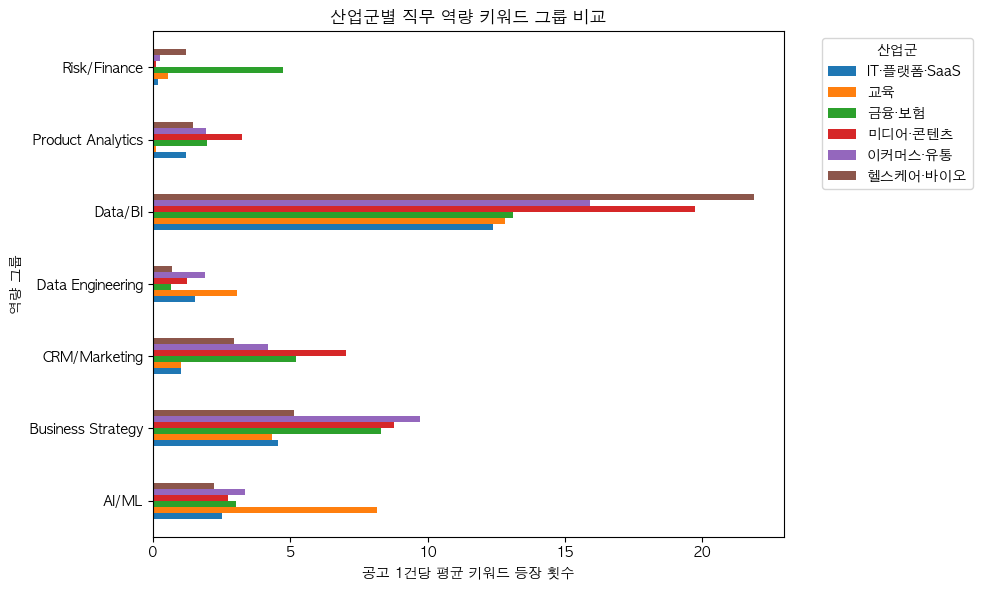

In [116]:
# 피벗테이블 생성
pivot_count = group_result.pivot(
    index="category",
    columns="industry",
    values="count_per_job"
)

display(pivot_count)

# 시각화
pivot_count.plot(kind="barh", figsize=(10, 6))

plt.title("산업군별 직무 역량 키워드 그룹 비교")
plt.xlabel("공고 1건당 평균 키워드 등장 횟수")
plt.ylabel("역량 그룹")
plt.legend(title="산업군", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [117]:
# 산업군별 상위 직무 역량 그룹 TOP 3
top_category_by_industry = (
    group_result
    .sort_values(["industry", "count_per_job"], ascending=[True, False])
    .groupby("industry")
    .head(3)
)

display(top_category_by_industry)


,industry,category,count,job_count,count_per_job
14,IT·플랫폼·SaaS,Data/BI,828,67,12.36
20,IT·플랫폼·SaaS,Business Strategy,304,67,4.54
18,IT·플랫폼·SaaS,AI/ML,168,67,2.51
35,교육,Data/BI,359,28,12.82
39,교육,AI/ML,228,28,8.14
41,교육,Business Strategy,121,28,4.32
0,금융·보험,Data/BI,630,48,13.12
6,금융·보험,Business Strategy,399,48,8.31
1,금융·보험,CRM/Marketing,250,48,5.21
21,미디어·콘텐츠,Data/BI,947,48,19.73


### 산업군별 직무 역량 비교 분석
- 모든 산업군에서 Data/BI 역량이 가장 높은 비중을 차지하여 데이터 추출·분석·시각화 역량이 데이터 분석 직무의 핵심 기반임을 확인함.
- 금융·보험은 CRM 및 고객 분석, 이커머스·유통은 비즈니스 전략 및 성과 분석, 
- 교육 산업은 AI/ML 관련 역량 수요가 상대적으로 높게 나타나 산업군별로 데이터 분석가에게 기대하는 역할이 다름을 확인하였음.

## 6. 텍스트 분석

In [159]:
# 불용어 설정
STOPWORDS = {
    '및', '의', '을', '를', '이', '가', '은', '는', '에', '에서', '으로', '로', '과', '와',
    '한', '하는', '하여', '하고', '있는', '있습니다', '합니다', '위한', '통해', '대한',
    '관련', '등', '수', '더', '또한', '이를', '이런', '이후', '함께', '기반', '활용',
    '업무', '경험', '분석', '데이터', '팀', '능력', '역량', '담당', '수행', '개발',
    '서비스', '기업', '회사', '운영', '관리', '지원', '결과', '통한',
    '위해', '내', '직무', '채용', '모집', '채용공고', '지원자', '담당자', '전문가',
    '이상', '이하', '가능', '필요', '보유', '우대', '자격', '요건', '우리', '저희',
    '경험이', '있으신', '보유하신', '데이터를', '활용한', '기반으로', '분석을', '문제를',
    '결과를', '인사이트를', '이상의', '가능한', '경험을', 'and', 'to', 'or', 'the',
    'of', 'in', 'for', 'with', 'Data', '또는', '분석가', '취소될', '채용이',
    '포지션', '자격요건', '발견될', '경우', '면접일정은', '추후', '통보됩니다', '최종합격',
    '있습니다', '있습니다.', '경력', '있습니다만', '있음', '지원', '채용', '관련된',
    '보유자', '보유하고', '보유한', '있으며', '통해', '따라',
    "있으며", "있고", "합니다", "됩니다",
    "전형절차", "서류전형", "면접전형", "최종합격", "합격자",
    "유의사항", "허위사실", "급여수준", "경력사항", "내규에", "의거하여",
    "지원자격", "학력", "학사", "석사", "경력", "년", "개월",
    "2026년", "6월", "50", "무제한", "제출", "제공", "급여",
    "South", "Korea", "skills", "ability", " 모집분야", "근무지", "인원", 
    "협의하여", "결정" "학위", "소지자", "담당업무", "우대사항", "서울", "메뉴"
}

def get_keywords(texts, top_n=20):
    words = []

    for desc in texts:
        ws = re.findall(r'[가-힣a-zA-Z0-9\+\#\.]{2,}', str(desc))

        for w in ws:
            w = w.strip()

            if w not in STOPWORDS and len(w) >= 2:
                words.append(w)

    return Counter(words).most_common(top_n)


def get_phrases(texts, top_n=20):
    phrases = []

    for desc in texts:
        text = re.sub(r'[\n\r•\-·.,()]', ' ', str(desc))
        words = re.findall(r'[가-힣a-zA-Z0-9\+\#\.]{2,}', text)

        words = [
            w.strip().replace(".", "")
            for w in words
            if w.strip().replace(".", "") not in STOPWORDS
        ]

        for i in range(len(words) - 1):
            if words[i] not in STOPWORDS and words[i+1] not in STOPWORDS:
                phrases.append(words[i] + " " + words[i+1])

    return Counter(phrases).most_common(top_n)

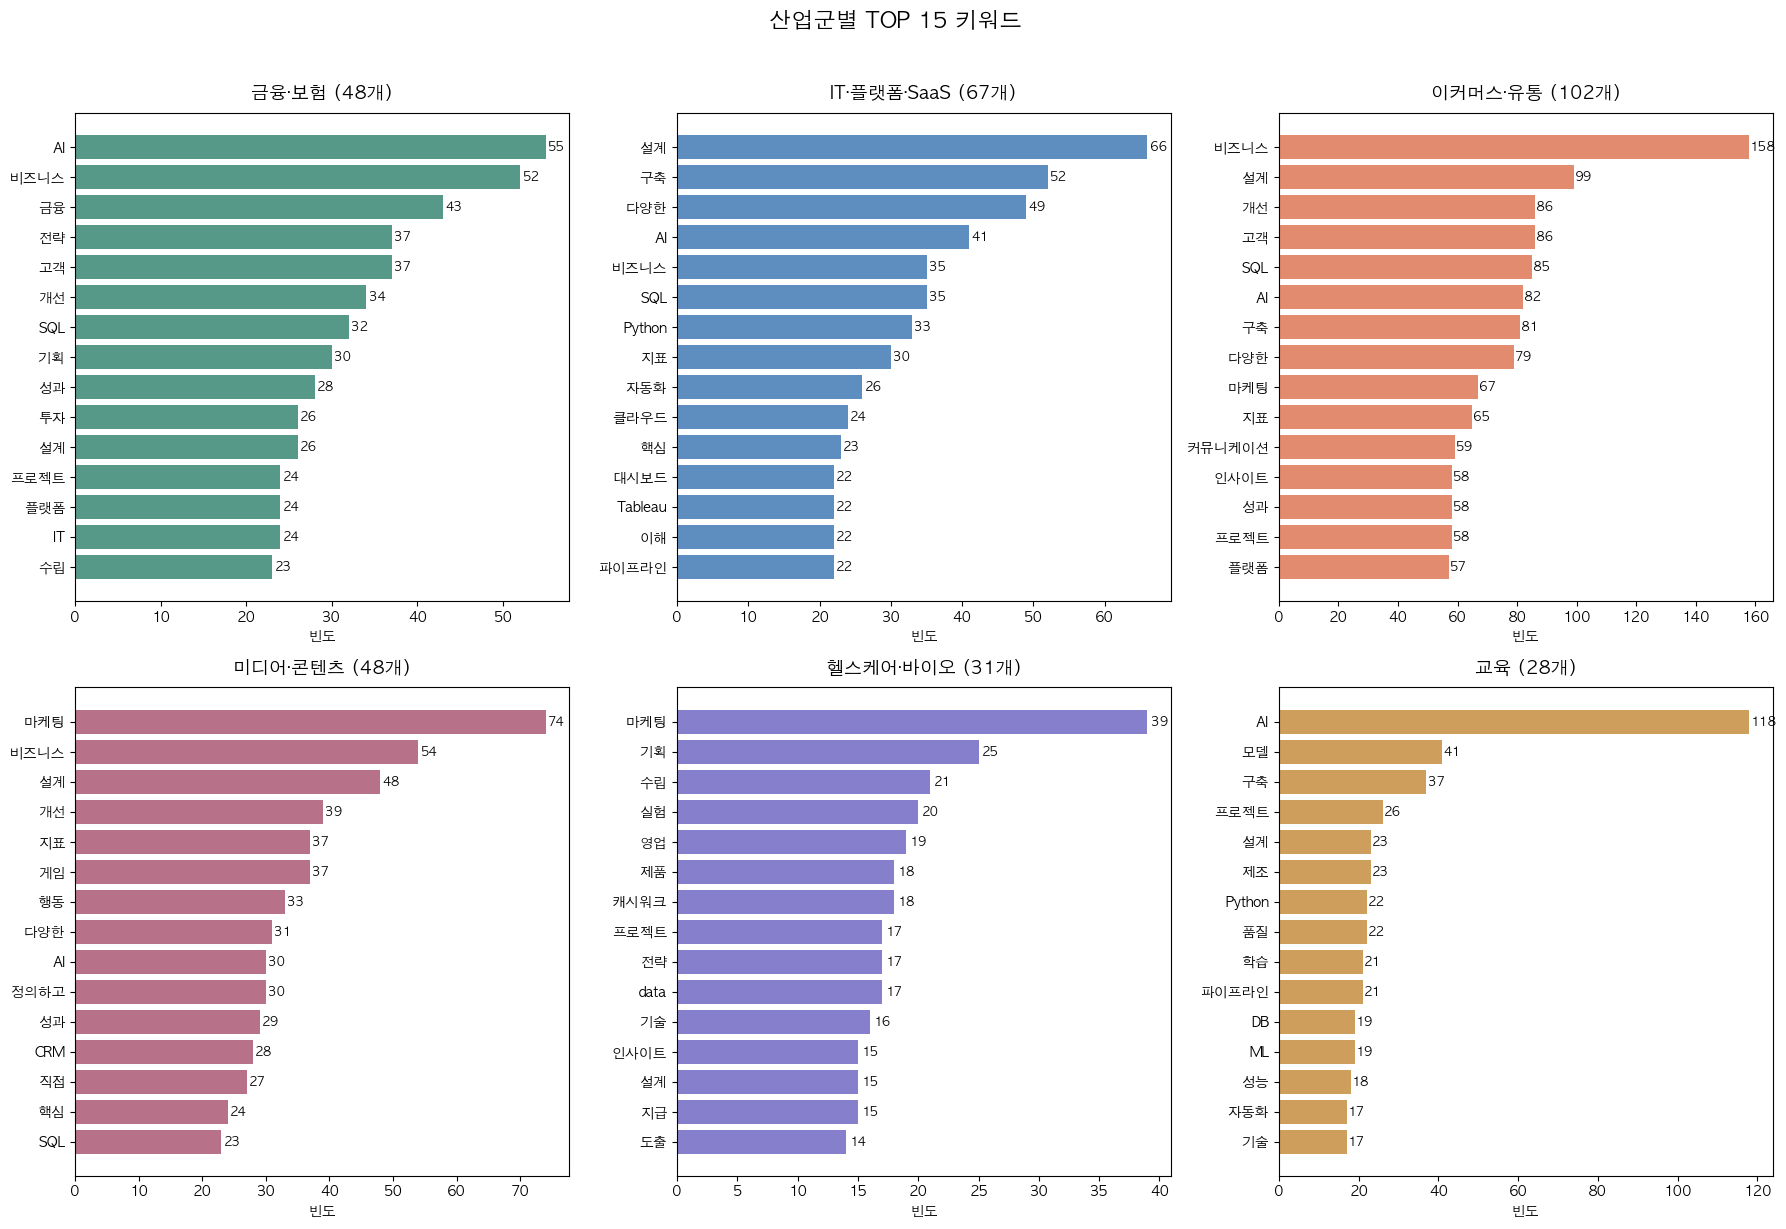

In [160]:
# ── 산업군별 키워드 분석 ──────────────────────────────────────────
industries = {
    '금융·보험': '#0F6E56',
    'IT·플랫폼·SaaS': '#185FA5',
    '이커머스·유통': '#D85A30',
    '미디어·콘텐츠': '#993556',
    '헬스케어·바이오': '#534AB7',
    '교육': '#BA7517',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (industry, color) in enumerate(industries.items()):
    subset = df[df['industry'] == industry]
    if len(subset) == 0:
        continue

    keywords = get_keywords(subset['description'], top_n=15)
    if not keywords:
        continue

    words, counts = zip(*keywords)
    ax = axes[idx]
    bars = ax.barh(list(words)[::-1], list(counts)[::-1], color=color, alpha=0.7)
    ax.set_title(f'{industry} ({len(subset)}개)', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('빈도', fontsize=10)
    ax.tick_params(axis='y', labelsize=10)

    for bar, count in zip(bars, list(counts)[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(count), va='center', fontsize=9)

plt.suptitle('산업군별 TOP 15 키워드', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


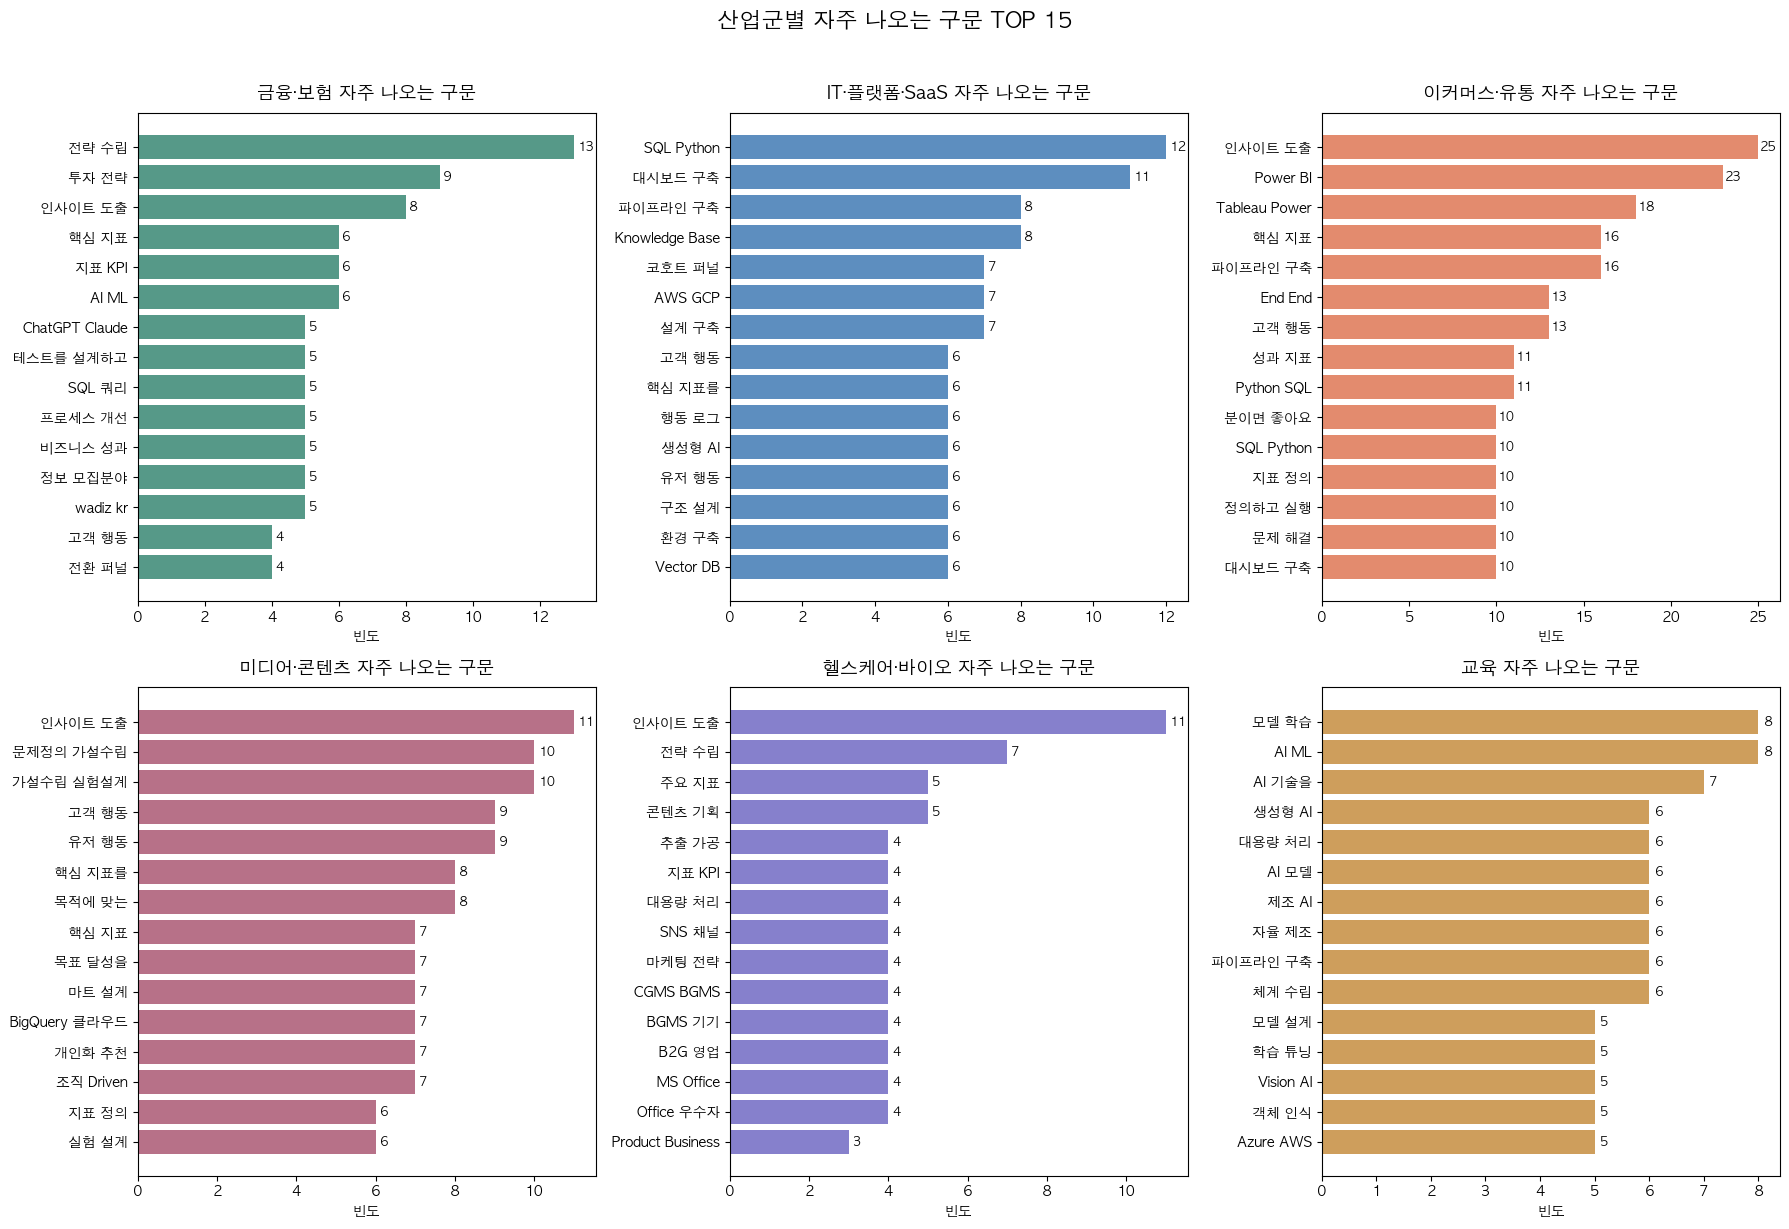

In [161]:
# ── 산업군별 구문 분석 ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (industry, color) in enumerate(industries.items()):
    subset = df[df['industry'] == industry]
    if len(subset) == 0:
        continue

    phrases = get_phrases(subset['description'], top_n=15)
    if not phrases:
        continue

    words, counts = zip(*phrases)
    ax = axes[idx]
    bars = ax.barh(list(words)[::-1], list(counts)[::-1], color=color, alpha=0.7)
    ax.set_title(f'{industry} 자주 나오는 구문', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('빈도', fontsize=10)
    ax.tick_params(axis='y', labelsize=10)

    for bar, count in zip(bars, list(counts)[::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                str(count), va='center', fontsize=9)

plt.suptitle('산업군별 자주 나오는 구문 TOP 15', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

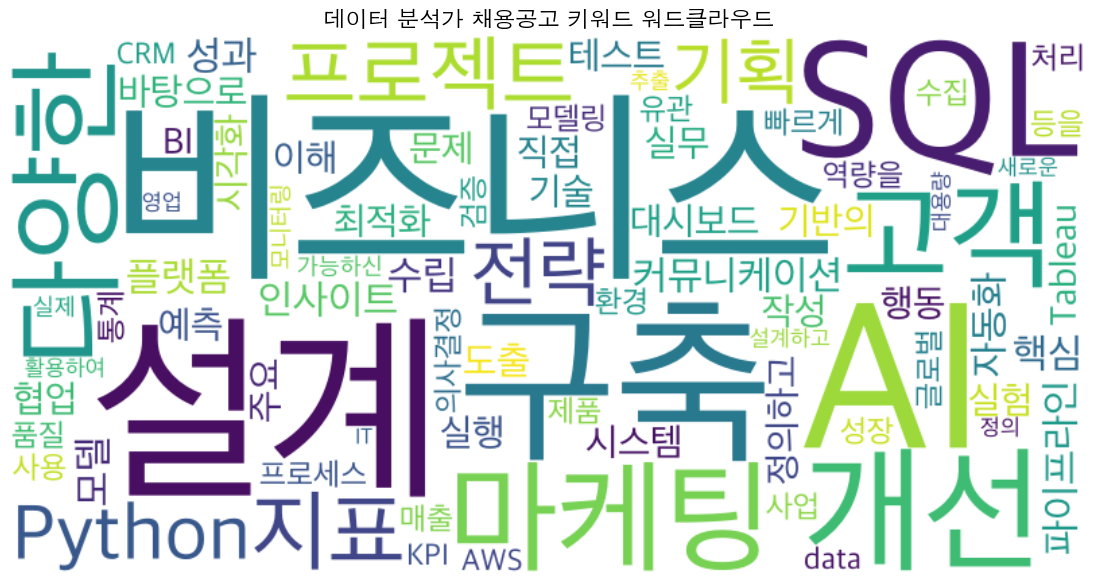

In [162]:
# ── 전체 워드클라우드 (선택) ──────────────────────────────────────────
from wordcloud import WordCloud

all_words = []
for desc in df['description'].dropna():
    ws = re.findall(r'[가-힣a-zA-Z\+\#]{2,}', str(desc))
    for w in ws:
        if w not in STOPWORDS and len(w) >= 2:
            all_words.append(w)

word_freq = dict(Counter(all_words).most_common(100))

wc = WordCloud(
    font_path='/System/Library/Fonts/AppleSDGothicNeo.ttc',
    width=800, height=400,
    background_color='white',
    max_words=80,
    colormap='viridis'
).generate_from_frequencies(word_freq)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('데이터 분석가 채용공고 키워드 워드클라우드', fontsize=16, fontweight='bold')
plt.show()

### 텍스트 분석 결과
스킬 키워드 분석만으로는 산업군별 데이터 분석가의 역할 차이를 충분히 설명하기 어려워  
이에 채용공고 Description 텍스트를 대상으로 불용어 제거 후 키워드 및 2-gram(구문) 분석을 수행하여 산업군별로 반복적으로 등장하는 직무 표현과 요구 역량을 비교하였음.

- 금융·보험 산업군은 고객 데이터와 비즈니스 성과를 기반으로 의사결정을 지원하는 역할이 강조되었음.  
특히 전략 수립, KPI 관리, 투자 전략, AI 활용 관련 표현이 반복적으로 등장하여 단순 데이터 추출보다. 
비즈니스 문제 해결 및 성과 관리 중심의 분석 역량 수요가 높게 나타났음.

- IT·플랫폼 산업군은 SQL·Python 기반 분석 역량 외에도 데이터 파이프라인, 클라우드 환경, 생성형 AI 관련 기술 역량이 함께 요구되었음.  
분석뿐 아니라 데이터 인프라와 자동화에 대한 이해를 기대하는 특징이 확인되었음.

- 이커머스 산업군은 고객 행동 분석을 통해 성과 개선 인사이트를 도출하는 역할이 강조되었음.  
또한 Tableau, Power BI 등 BI 도구 활용 표현이 자주 등장하여 Product Analytics 및 마케팅 성과 분석 중심의 업무 특성이 나타났음.

## 7. 결론 및 한계점 정리

### 결론
430건의 데이터 분석 채용공고를 분석한 결과 SQL은 전체 산업군에서 가장 보편적으로 요구되는 핵심 역량으로 확인되었으며,  

Python과 Tableau 등 데이터 분석 및 시각화 역량 수요도 높게 나타났음.

산업군별로는 이커머스·유통, IT·플랫폼·SaaS, 금융·보험 순으로 채용 수요가 높게 나타났으며, 요구 역량에도 차이가 존재하였음.  

금융·보험 산업군은 KPI, 고객 분석, 전략 수립 등 비즈니스 의사결정 지원 역량이 강조되었고,  

이커머스·유통 산업군은 고객 행동. 분석, 성과 측정, BI 도구 활용 등 Product Analytics 역량 수요가 높게 나타났음.  

IT·플랫폼·SaaS 산업군은 SQL·Python 기반 분석 역량 외에도 데이터 파이프라인, 클라우드, AI 활용 등 기술적 역량 요구 비중이 상대적으로 높게 확인되었음.

이를 통해 데이터 분석 직무는 산업군에 따라 세부 역할은 다르지만, 공통적으로 데이터 기반 문제 해결과 비즈니스 의사결정 지원 역할을 수행하고 있음을 확인함.

### 한계점
① Rule-Based 스킬 추출

본 분석은 사전에 정의한 스킬 사전을 기반으로 스킬을 추출함.

따라서 새로운 기술명이나 유사 표현이 누락될 수 있으며, 실제 요구 역량을 완전히 반영하지 못할 가능성이 존재

② 산업군 분류 한계

산업군은 회사명 및 공고 내용을 기준으로 Rule-Based 방식으로 분류함.

일부 기업은 여러 산업 특성을 동시에 보유하고 있어 오분류 가능성이 존재

③ 텍스트 분석 한계

채용공고 텍스트에는 공통 채용 문구가 다수 포함되어 있어 불용어 제거를 수행하였으나 일부 노이즈가 남아 있을 수 있음.
또한 단순 빈도 기반 분석이므로 문맥과 중요도를 완전히 반영하지 못함.

④ 데이터 수집 범위 한계

사람인, 잡코리아, 원티드, 리멤버 4개 플랫폼을 대상으로 수집하였으나 모든 데이터 분석 채용공고를 포함하지는 않음.

플랫폼별 특성에 따라 특정 산업군이 과대 또는 과소 대표될 가능성이 존재함.